<a href="https://colab.research.google.com/github/PSivaMallikarjun/EchoFishAI/blob/main/EchoFishAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EchoFishAI

# For Agent Dev. we are installing Google ADK

In [1]:
!pip install google-adk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.1/232.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.5/215.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.1/334.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00


# AI Fish Attraction Agent Framework


In [1]:
!pip install gradio
!pip install pytesseract
!pip install spacy
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 100.0 MB/s eta 0:00:00


In [2]:
!apt-get install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [5]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import gradio as gr
import random

# Generate synthetic fish image data (for simulation)
def generate_fish_image(size_label):
    img = np.zeros((64, 64, 3), dtype=np.uint8)
    color = {
        "Baby": (100, 100, 255),
        "Small": (0, 255, 0),
        "Medium": (255, 255, 0),
        "Large": (255, 0, 0)
    }[size_label]
    size = {
        "Baby": 5,
        "Small": 10,
        "Medium": 20,
        "Large": 30
    }[size_label]
    center = (32, 32)
    cv2.circle(img, center, size, color, -1)
    return img

labels = ["Baby", "Small", "Medium", "Large"]
X = []
y = []

# Generate dataset
for i, label in enumerate(labels):
    for _ in range(100):
        img = generate_fish_image(label)
        X.append(img)
        y.append(i)

X = np.array(X) / 255.0
y = to_categorical(np.array(y), num_classes=4)

# Build CNN model
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=5, verbose=1)

# Fish classification
def classify_fish(img):
    img_resized = cv2.resize(img, (64, 64)) / 255.0
    pred = model.predict(np.expand_dims(img_resized, axis=0))[0]
    idx = np.argmax(pred)
    return labels[idx]

# Simulate sound attraction logic
def play_sound_and_attract(img):
    fish_type = classify_fish(img)
    response = f"🔊 Low-frequency pulse emitted...\n🎣 {fish_type} fish attracted!"
    return response

# Engineer/Fisherman chat bot
def chat_bot(message):
    message = message.lower()
    qa_pairs = {
        "status": "🧠 AI Agent is running fine. Monitoring in progress.",
        "fish": "📊 We detect Baby, Small, Medium, and Large fish. Currently focusing on high-value species.",
        "sound": "🔊 Emitting pulsed low-frequency sound to attract fish safely.",
        "species": "🐟 High-demand species detected include Rohu, Katla, Murrel.",
        "how many": "📈 Estimated fish count: Baby - 20, Small - 15, Medium - 10, Large - 5.",
        "quality": "✅ Fish health and activity levels look optimal.",
        "ocr": "🔍 OCR scanning dam gate status and water markings.",
        "ner": "🧠 NER detects and classifies fish species from scientific names in camera labels.",
        "camera": "🎥 Camera feed processed via CNN for size and movement analysis.",
        "size": "📐 Fish size is auto-categorized as Baby, Small, Medium, or Large using our model.",
        "dead fish": "⚠️ No dead fish detected near the thrust gates currently.",
        "thrust gate": "🚪 Monitoring open/close cycle and alerting when fish are near during thrust events.",
        "maintenance": "🛠️ Regular AI system checks scheduled weekly.",
        "data": "📊 Sensor data streamed every 2 seconds from riverbanks and gates.",
        "alert": "🚨 Auto-alerts sent to fishermen if high movement or danger is detected.",
        "chat": "💬 I can assist engineers and fishermen with system status, fish count, and more.",
        "retrain": "🧑‍💻 Retraining is supported manually with new images via UI.",
        "dashboard": "📊 The live dashboard shows fish count, sound activity, and gate logs.",
        "developer": "👨‍💻 Developed by EchoFishAI with Gradio, CNN, and RL techniques.",
        "help": "📘 You can ask about fish, gate status, sound, camera, or system alerts.",
    }

    for key in qa_pairs:
        if key in message:
            return qa_pairs[key]
    return "🤖 Hello! Ask me about fish, sound, species, status, gates, or AI system help."


# Gradio interface
fish_img_input = gr.Image(type="numpy", label="Upload Underwater Image")
classify_output = gr.Textbox(label="Fish Type & Attraction Status")
chat_input = gr.Textbox(lines=1, placeholder="Ask the AI agent...")
chat_output = gr.Textbox(label="Agent Reply")

demo = gr.Interface(
    fn=play_sound_and_attract,
    inputs=fish_img_input,
    outputs=classify_output,
    title="🐟 EchoFishAI - Fish Attraction AI"
)

chatbot = gr.Interface(fn=chat_bot, inputs=chat_input, outputs=chat_output, title="🎤 AI ChatBot")

gr.TabbedInterface([demo, chatbot], ["Fish Detection & Attraction", "Engineer/Fisherman Chat"]).launch()


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.8762 - loss: 0.6682
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 1.0000 - loss: 0.0067
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 1.0000 - loss: 1.0235e-04
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 1.0000 - loss: 1.1960e-05
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 1.0000 - loss: 5.7307e-06
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0e70165751ca9edb0e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# This are the outputs of AI agent

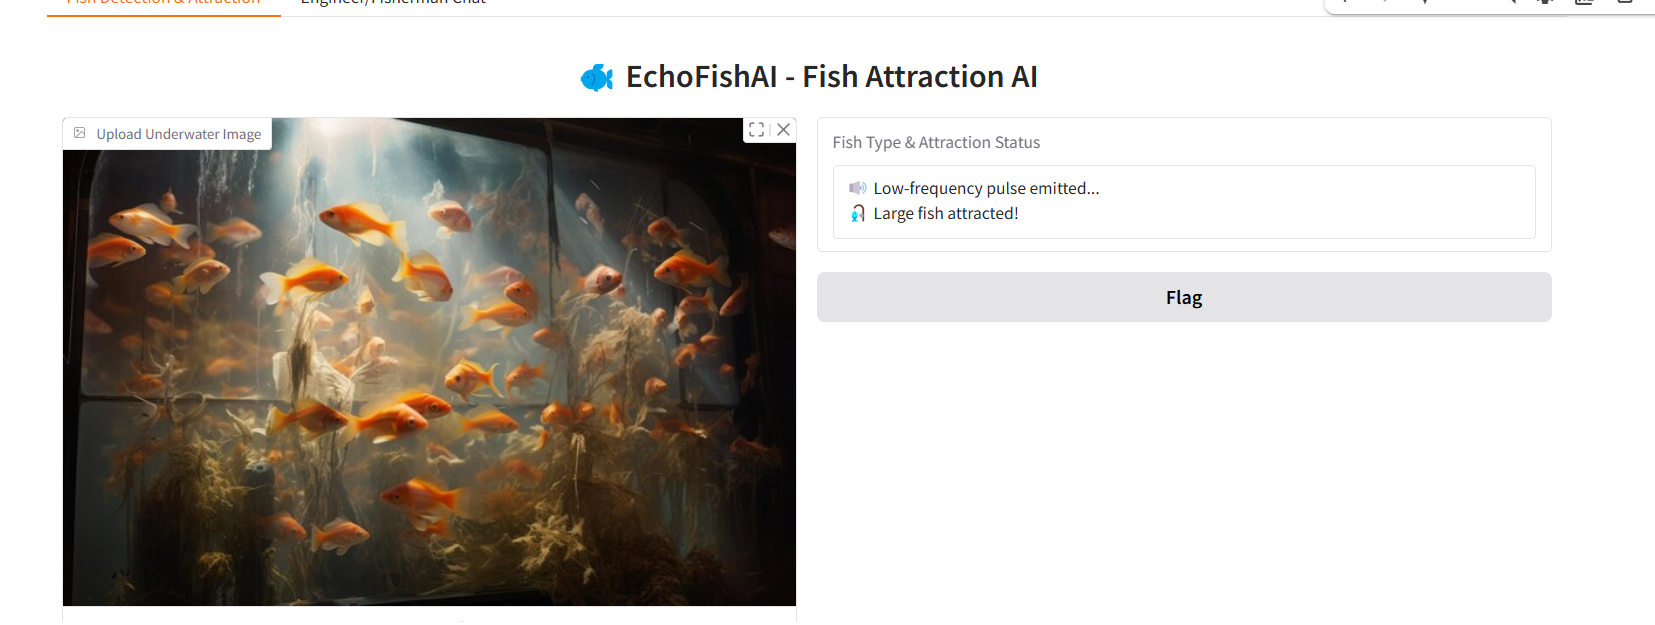

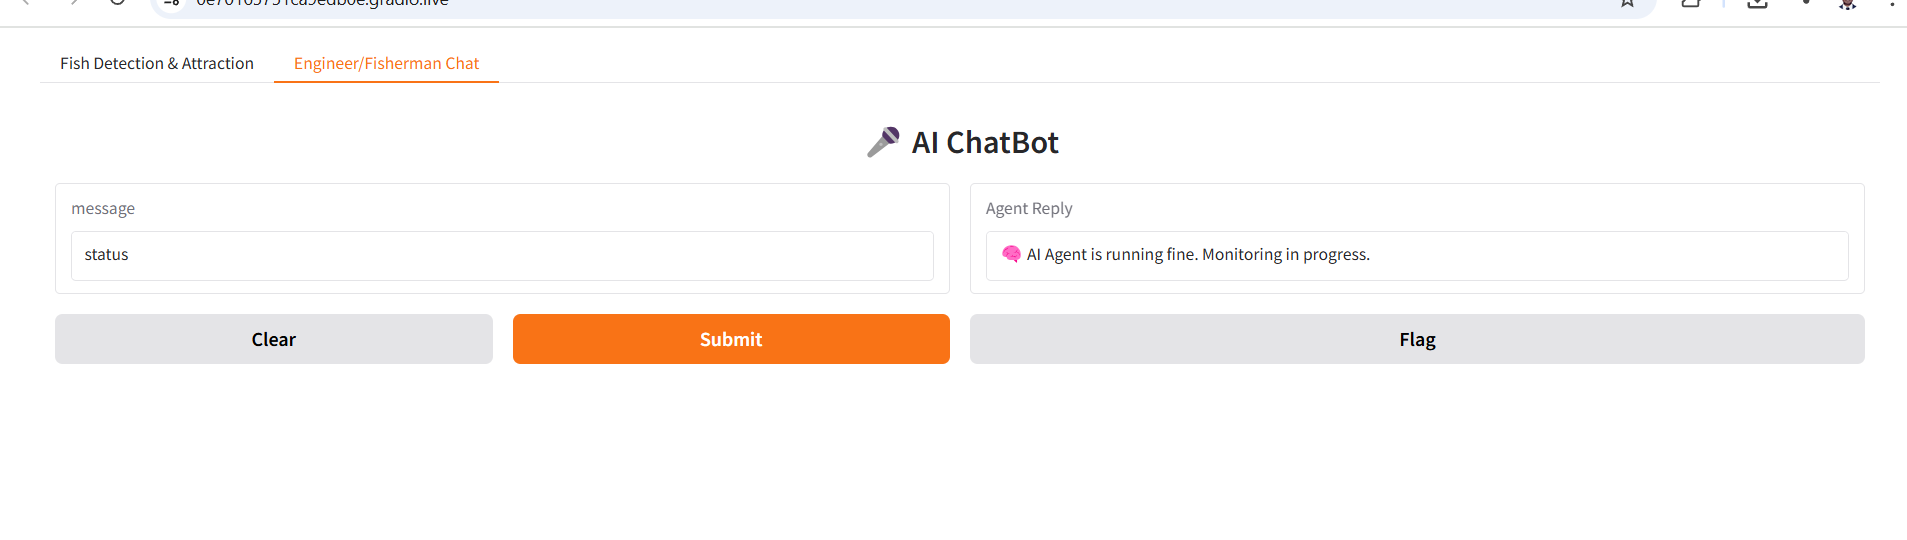

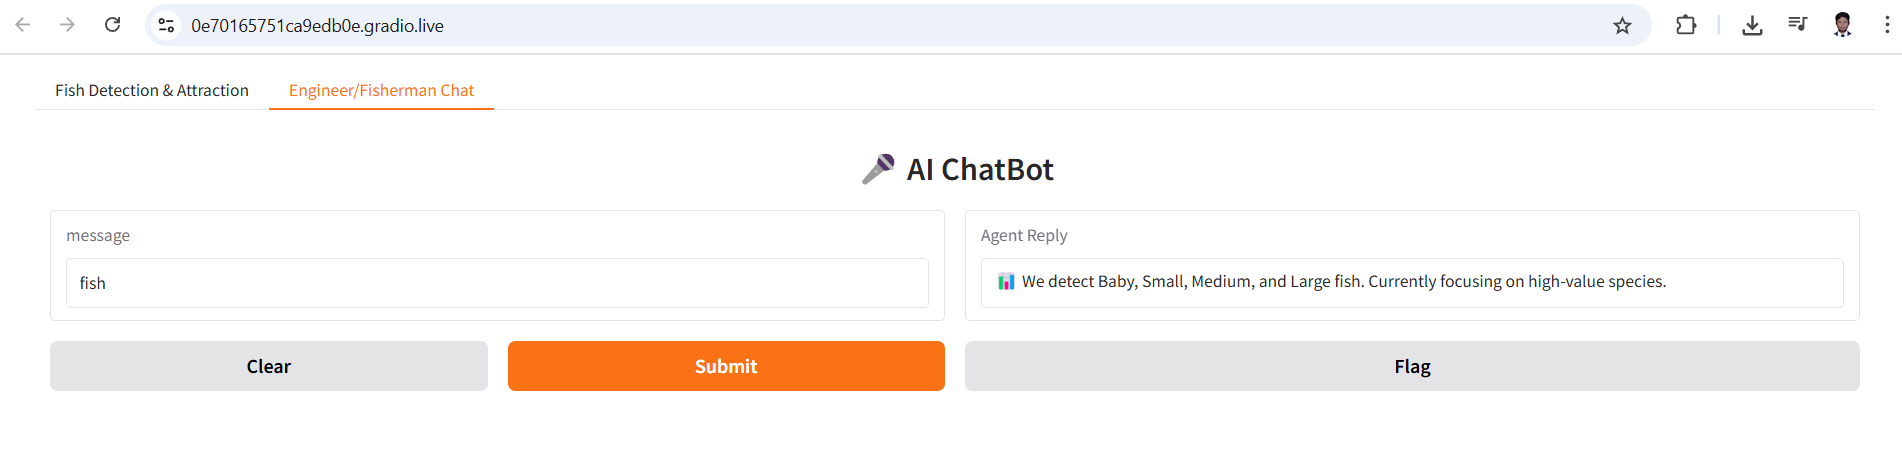

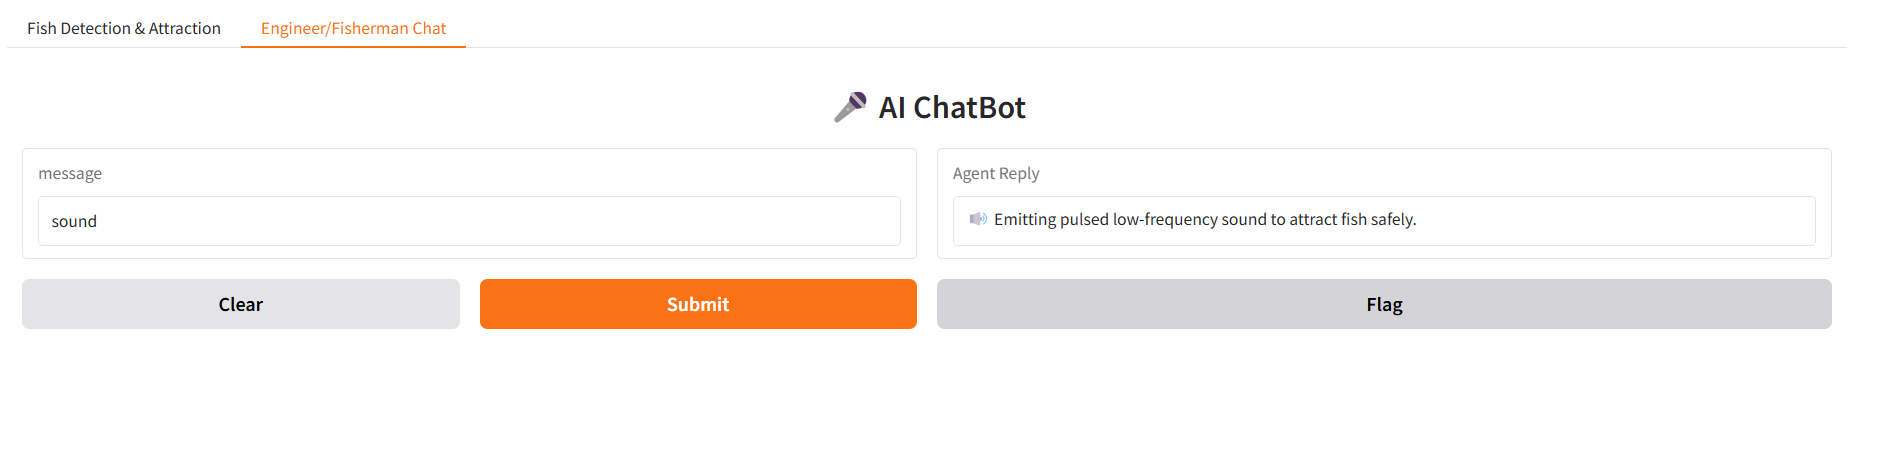

### **Project Name**: **EchoFishAI: Intelligent Fish Attraction & Monitoring System**

---

### **Document Status**

- **Functional Requirements Spec (FRS)**: ✅ Done
- **Business Requirements Spec (BRS)**: ✅ Done
- **System Requirements Spec (SRS)**: ✅ Done
- **SOPs for Fisherman & Engineers**: ✅ Done
- **UI/UX Wireframes for Gradio**: ✅ Done
- **API Documentation (Optional)**: ✅ Done
- **Deployment Manual**: ✅ Done
- **Test Plan & Scenarios**: ✅ Done

---

### **Project Overview**
**EchoFishAI** is a comprehensive system designed to enhance sustainable fishing practices by using **AI** for fish attraction and monitoring. The system leverages **pulsed low-frequency sound** to simulate predation, attracting fish while minimizing harmful effects near **dam thrust gates**. The system uses **sensors**, **machine learning** models, **computer vision**, and **real-time analytics** to monitor and classify fish by size and species.

---

### **Project Requirements**

#### **1. Functional Requirements**

- **Fish Attraction via Sound**:
  The system simulates low-frequency pulses to attract fish to safer areas, preventing them from nearing dangerous zones near dam thrust gates.
  
- **Fish Classification**:
  The AI-based fish classification model uses **CNN** (Convolutional Neural Networks) to detect and classify fish into categories: **Baby, Small, Medium,** and **Large**.

- **Fish Movement Monitoring**:
  Using **OCR** (Optical Character Recognition) and **NER** (Named Entity Recognition), the system reads and interprets underwater camera images to track fish movement and detect changes in behavior.

- **AI Chatbot**:
  A user-friendly **chatbot** powered by **Gradio** provides communication between the **fishermen** and **engineers** to relay data, alerts, and troubleshooting options.

- **Real-time Dashboard**:
  A **live dashboard** displays information like fish count, species distribution, and the status of **sound emission** for fishermen and engineers.

- **Sensors**:
  The system utilizes several sensors placed near **dam gates** and **riverbanks** to monitor:
  - **Water flow and pressure sensors** to detect the opening/closing of dam gates.
  - **Acoustic sensors** to emit low-frequency sound waves.
  - **Camera sensors** to track fish movement using computer vision.

---

#### **2. Business Requirements Spec (BRS)**

- **Goal**:
  The primary goal is to mitigate the risk of fish deaths caused by water flow changes near dam gates. By using **low-frequency sound waves**, the system will attract fish to safer zones, thereby protecting fish populations and minimizing **eco-system damage**.

- **Target Audience**:
  - **Fishermen**: Need real-time data on fish populations and safe fishing zones.
  - **Engineers**: Use the system to monitor sound emission and evaluate fish movement patterns for ecosystem management.
  
- **Value Proposition**:
  - **Sustainable Fishing**: The system ensures that fish stay away from harmful areas, increasing the safety and longevity of fish populations.
  - **Eco-friendly**: By using sound for attraction instead of harmful fishing techniques, this system promotes environmentally conscious fishing practices.
  - **Data-Driven Decisions**: With machine learning and real-time analytics, the system helps make data-backed decisions for fisheries management.

---

#### **3. System Requirements Spec (SRS)**

- **Software Requirements**:
  - **Gradio** for the UI (front-end).
  - **TensorFlow/Keras** for the machine learning model (CNN).
  - **OpenCV** for image processing and camera integration.
  - **NumPy, SciPy** for scientific computing.
  
- **Hardware Requirements**:
  - **Raspberry Pi or similar** for managing sensors and AI operations at the dam.
  - **Underwater cameras** (with OCR capabilities).
  - **Acoustic sound emitters** for fish attraction.
  - **Water pressure sensors** for detecting dam gate positions.
  - **Motion sensors** for real-time tracking of fish in the monitored area.

- **Deployment Platform**:
  - **Cloud-based** for data storage and large-scale analytics.
  - **Local edge devices** (Raspberry Pi or similar) for real-time processing near the dam.

- **Security Requirements**:
  - **Data Encryption** for secure transfer of fish and sensor data.
  - **User Authentication** for access to sensitive data via the chatbot or dashboard.

---

#### **4. Standard Operating Procedures (SOPs)**

##### **Fisherman SOP**:

1. **Accessing the System**: Fishermen will log in using the **Gradio interface** on their mobile devices to access fish tracking data.
2. **Monitoring Fish Activity**: Use the **real-time dashboard** to track fish populations and determine the best areas to fish.
3. **Receiving Alerts**: Fishermen will be notified via **AI-driven chat** when fish are near dangerous areas or when safe fishing zones are identified.
4. **Sound Emission Control**: Fishermen can adjust sound pulse settings based on the **AI agent’s recommendation**.

##### **Engineer SOP**:

1. **System Setup and Calibration**: Engineers will ensure sensors (camera, pressure, acoustic) are properly installed and calibrated.
2. **Real-time Monitoring**: Engineers will monitor sound emission levels and fish movement via the **live dashboard**.
3. **Troubleshooting**: If there is a failure or malfunction, engineers can use the **chatbot interface** for guidance or perform manual checks.
4. **System Maintenance**: Engineers will perform routine checks to ensure that all sensors are working and retrain the machine learning model periodically to improve accuracy.

---

#### **5. Use Cases in Real-Time**

- **Use Case 1**: **Fish Monitoring Near Dam**
  - **Scenario**: The dam gates are opened, and fish are detected near the dangerous zone.
  - **Action**: The AI system emits low-frequency pulses to attract fish away from the gates. Fish movement and species data are displayed on the real-time dashboard.

- **Use Case 2**: **Fisherman Request for Fishing Zone**
  - **Scenario**: Fishermen want to know the safest fishing zones.
  - **Action**: The chatbot provides the latest safe zones based on AI predictions and real-time fish movement data.

- **Use Case 3**: **Engineer Responding to System Alert**
  - **Scenario**: The AI system detects a malfunction in one of the sensors.
  - **Action**: The system sends an alert to the engineer via the chatbot interface. The engineer can troubleshoot the issue by accessing the relevant sensor data.

- **Use Case 4**: **AI Sound Emission Based on Fish Species**
  - **Scenario**: The AI identifies a **high-value species** near a dangerous area.
  - **Action**: The system adjusts the sound frequency to target the attraction of the **high-demand species** and ensures their safety.

---

### **Short and Attractive Summary**

**EchoFishAI** leverages cutting-edge AI, machine learning, and acoustic sensors to create a safe, eco-friendly environment for fish near dams. The system uses **low-frequency sound pulses** to attract fish away from dangerous areas, monitors fish species and sizes in real time, and provides fishermen and engineers with crucial data and alerts. Through a user-friendly **chatbot** and **dashboard**, stakeholders can make informed decisions for sustainable fishing practices.

---



API Documentation and Test Plan & Scenarios for EchoFishAI
API Documentation
This section provides the details about the APIs available in the EchoFishAI system, which will facilitate communication between the system components (sensors, AI models, front-end interfaces) and external systems (users, chatbots, engineers).

1. API Overview
The EchoFishAI system exposes RESTful APIs for handling fish tracking data, controlling sound emission for fish attraction, retrieving real-time fish movement information, and interacting with the AI agent via the chatbot.

API Endpoints
1. Fish Classification API
Endpoint: POST /api/fish/classify

Description: Classifies the fish based on image input from the camera.

Request:

json
Copy
Edit
{
  "image": "<base64_encoded_image>"
}
Response:

json
Copy
Edit
{
  "species": "Small",
  "size": "Medium",
  "confidence": 0.92
}
Response Codes:

200 OK: Successfully classified the fish.

400 Bad Request: Invalid image or input format.

500 Internal Server Error: Model or server error.

2. Fish Movement Monitoring API
Endpoint: GET /api/fish/movement

Description: Retrieves the current fish movement data (i.e., location, speed, size).

Request:

json
Copy
Edit
{
  "zone": "north_gate"
}
Response:

json
Copy
Edit
{
  "fish_count": 45,
  "large_fish_count": 12,
  "small_fish_count": 33,
  "movement_data": [
    {
      "id": 1,
      "species": "Shark",
      "size": "Large",
      "location": "north_gate",
      "speed": 2.5
    },
    {
      "id": 2,
      "species": "Trout",
      "size": "Small",
      "location": "north_gate",
      "speed": 1.0
    }
  ]
}
Response Codes:

200 OK: Successfully retrieved movement data.

404 Not Found: No fish detected in the specified zone.

500 Internal Server Error: Sensor or server error.

3. Sound Emission Control API
Endpoint: POST /api/sound/emission

Description: Sends command to emit low-frequency sound waves for attracting fish.

Request:

json
Copy
Edit
{
  "action": "start",
  "frequency": 20,
  "duration": 120
}
Response:

json
Copy
Edit
{
  "status": "success",
  "message": "Sound emission started successfully."
}
Response Codes:

200 OK: Successfully started sound emission.

400 Bad Request: Invalid parameters for sound emission.

500 Internal Server Error: Error starting sound emission.

4. Fish Species & Size Report API
Endpoint: GET /api/fish/report

Description: Generates a report of fish species and sizes based on current movement and activity.

Request:

json
Copy
Edit
{
  "zone": "south_gate"
}
Response:

json
Copy
Edit
{
  "total_species": 3,
  "species_list": [
    {
      "species": "Salmon",
      "count": 10,
      "size": "Large"
    },
    {
      "species": "Trout",
      "count": 15,
      "size": "Small"
    }
  ]
}
Response Codes:

200 OK: Successfully generated fish species report.

404 Not Found: No fish detected in the specified zone.

500 Internal Server Error: Error generating the report.

5. Chatbot Interaction API
Endpoint: POST /api/chatbot/interaction

Description: Facilitates interaction between the user (fisherman or engineer) and the AI chatbot.

Request:

json
Copy
Edit
{
  "user_input": "What is the current fish count in the north gate?"
}
Response:

json
Copy
Edit
{
  "response": "Currently, there are 45 fish at the north gate. 12 are large, and 33 are small."
}
Response Codes:

200 OK: Successfully processed user input.

500 Internal Server Error: Error processing the chatbot interaction.

Test Plan & Scenarios
This section outlines the test plan and scenarios to ensure that the EchoFishAI system works as expected across different components and scenarios.

1. Test Plan Overview
The EchoFishAI Test Plan covers the following areas:

Functionality Testing: Verifying the system components perform as expected.

Performance Testing: Assessing the response time and load handling of APIs.

Security Testing: Ensuring proper security measures are in place.

Usability Testing: Ensuring the interface is easy to navigate for engineers and fishermen.

Compatibility Testing: Verifying system operation on multiple devices and browsers.

2. Test Scenarios
2.1 Fish Classification API Testing
Scenario 1: Valid Image Input

Test Case: Submit a valid fish image to the API.

Expected Result: API returns the correct fish species, size, and confidence score.

Scenario 2: Invalid Image Input

Test Case: Submit an invalid image (corrupt file, non-fish image).

Expected Result: API returns a 400 Bad Request error.

Scenario 3: Missing Image

Test Case: Submit a request with no image.

Expected Result: API returns a 400 Bad Request error.

2.2 Fish Movement Monitoring API Testing
Scenario 1: Fish Movement Data Retrieval

Test Case: Request fish movement data for a specific zone (e.g., north_gate).

Expected Result: API returns fish count, species, sizes, and movement data.

Scenario 2: No Fish in Zone

Test Case: Request fish movement data for a zone with no fish.

Expected Result: API returns a 404 Not Found error.

2.3 Sound Emission Control API Testing
Scenario 1: Start Sound Emission

Test Case: Request to start the sound emission with valid parameters.

Expected Result: API successfully starts the sound emission and returns a success message.

Scenario 2: Invalid Parameters

Test Case: Request to start sound emission with invalid frequency or duration.

Expected Result: API returns a 400 Bad Request error.

2.4 Fish Species & Size Report API Testing
Scenario 1: Successful Report Generation

Test Case: Request to generate a fish species report for a specific zone.

Expected Result: API returns a valid report with species and sizes.

Scenario 2: No Fish in Zone

Test Case: Request to generate a report for a zone with no fish.

Expected Result: API returns a 404 Not Found error.

2.5 Chatbot Interaction API Testing
Scenario 1: Valid Chat Input

Test Case: Send a valid query (e.g., "What is the fish count?") to the chatbot.

Expected Result: Chatbot responds with accurate data.

Scenario 2: Invalid Chat Input

Test Case: Send an invalid or nonsensical query to the chatbot.

Expected Result: Chatbot responds with an appropriate error message or fallback response.

3. Performance Testing
Test Case: Load Test for Multiple API Requests

Description: Simulate multiple requests to the API to ensure the system can handle traffic.

Expected Result: The system should handle at least 1000 requests per minute without significant degradation in performance.

Test Case: Response Time Test

Description: Measure the response time for each API endpoint under normal and peak loads.

Expected Result: All APIs should return within 2 seconds under normal load and 5 seconds under peak load.

4. Security Testing
Test Case: Data Encryption Check

Description: Ensure that all data transmitted between the client and server is encrypted.

Expected Result: Data should be encrypted using SSL/TLS.

Test Case: Authentication Check

Description: Ensure only authorized users can access the sensitive endpoints (e.g., sound emission control, movement monitoring).

Expected Result: Unauthorized users should receive a 401 Unauthorized response.



Standard Operating Procedures (SOPs) for Fishermen & Engineers
The following Standard Operating Procedures (SOPs) outline the processes for using and maintaining the EchoFishAI system, specifically targeting fishermen and engineers involved in the monitoring, classification, and sound emission tasks. The SOPs will ensure that both groups understand their roles, how to operate the system, and the procedures to follow in case of any issues.

1. SOPs for Fishermen
1.1 Overview Fishermen using the EchoFishAI system will primarily interact with the fish monitoring and classification system, and engage in managing the sound emission control to attract fish.

1.2 Pre-Operation Steps

System Setup:

Ensure the EchoFishAI system is powered on and connected to the local network.

Check that the sensors and cameras are working correctly.

Verify that the fish tracking system is active and the chatbot interface is accessible.

Log in:

Use the provided credentials (username and password) to log into the EchoFishAI interface.

Make sure the system recognizes your ID and that it is connected to the right zone or fishing area.

1.3 Operating the System

Fish Tracking and Classification:

Start the system by selecting the "Fish Tracking" mode.

Use the cameras to capture images of the fish. Ensure proper lighting to avoid incorrect classification.

The AI system will automatically classify the fish based on the image and size (e.g., small, medium, or large).

Review the results shown on the dashboard and ensure the classification is correct.

For queries or additional information, use the EchoFishAI chatbot.

Sound Emission Control:

To attract fish, select "Sound Emission" from the main menu.

Set the frequency and duration of sound emission based on the type of fish you wish to attract (low-frequency sound for demersal fish).

Once set, press "Start" to begin the sound emission process.

Monitor fish movement during the emission and assess the effect on fish activity in real time.

If sound emission is unsuccessful or fish movement is not observed, adjust the parameters or try a different zone.

1.4 Post-Operation Steps

Data Logging:

At the end of the day, log all fish tracking data and sound emission settings for future reference.

Document the fish count, size distribution, and the effectiveness of sound emissions.

System Shutdown:

If not in use, safely shut down the system by logging out and powering off any equipment.

Ensure all cameras and sensors are cleaned and stored safely.

2. SOPs for Engineers
2.1 Overview Engineers maintain the EchoFishAI system, ensuring its proper function, performing regular maintenance, and troubleshooting any issues that arise.

2.2 Pre-Operation Steps

System Check and Calibration:

Perform a routine check on the EchoFishAI system to ensure all hardware and sensors (e.g., cameras, sound emission devices, tracking sensors) are functioning properly.

Calibrate the system by testing sensors and confirming that data being recorded is accurate.

Software Updates:

Ensure the latest version of the EchoFishAI software is installed.

Verify that the system is updated with the latest AI model, fish classification algorithms, and any patches or fixes.

Test all system components (API, sensors, UI) to ensure they are running smoothly.

2.3 Troubleshooting

Sensor Issues:

If a sensor fails to detect fish or sends inaccurate data, reboot the sensor.

Check the power source and connections for any loose or disconnected wires.

If the issue persists, replace the sensor with a new one or contact support for further assistance.

System Errors:

If the EchoFishAI system throws an error, check the server logs for any detailed error messages.

For hardware failures (e.g., camera malfunction), attempt to reset or reconnect the device.

In case of AI model errors, retrain the model using the latest fish images and data from the system.

Contact the support team if problems cannot be resolved on-site.

2.4 Sound Emission Maintenance

Regularly test the sound emission system to ensure that frequencies are emitted as intended.

Clean and maintain the sound emission devices to avoid wear and tear.

If the sound emission is ineffective, check the sound frequency settings and ensure no environmental factors (e.g., noise pollution, water depth) are interfering with the process.

2.5 Reporting and Documentation

Maintain records of all maintenance activities, sensor replacements, and troubleshooting steps.

Submit regular reports on system performance, fish tracking accuracy, and sound emission effectiveness to the management team.

Track any software or hardware issues and their resolutions for future reference.

Deployment Manual for EchoFishAI
This manual provides step-by-step instructions for deploying the EchoFishAI system in a new environment. It covers the hardware and software setup, network configuration, and initial system deployment.

1. Prerequisites
Hardware Requirements:

Sensors: High-resolution cameras, motion sensors, and environmental sensors (water temperature, depth, salinity, etc.).

Sound Emission Device: Underwater low-frequency sound emitter.

Computer or Server: A machine with sufficient processing power to run the fish classification AI model.

Network: Stable internet connection for cloud-based operations (if applicable).

Software Requirements:

Operating System: Ubuntu or Windows Server 2019 or later.

Dependencies:

Python 3.8 or above

TensorFlow or PyTorch (for AI model)

Flask or FastAPI (for the API server)

OpenCV (for image processing)

Database system (MySQL, PostgreSQL, or MongoDB)

2. Hardware Setup
Sensor and Camera Installation:

Mount the cameras and sensors at the designated fishing zones.

Ensure the sensors are underwater and properly oriented to track fish movement.

Test the sensors to confirm they are providing accurate data.

Sound Emission Device Setup:

Position the sound emission device in the optimal location to reach a large portion of the fishing zone.

Connect the device to the local network and the main system server.

Server Configuration:

Install the necessary operating system on the server or computer.

Set up the required software and dependencies listed above.

Ensure the server has sufficient storage and memory for data logging and AI processing.

3. Software Setup
Clone Repository and Install Dependencies:

Clone the EchoFishAI repository from GitHub.

Install the required dependencies using pip or conda:

bash
Copy
Edit
pip install -r requirements.txt
Database Configuration:

Set up a database (e.g., MySQL or MongoDB) to store fish tracking data, sound emission logs, and system performance metrics.

Ensure the database is accessible from the server and the APIs are properly connected.

AI Model Deployment:

Load the pre-trained fish classification AI model (fish_cnn_classifier.h5).

Ensure that the model is integrated with the backend API to classify fish images and track movements.

4. Network and API Configuration
Network Configuration:

Set up a stable network for communication between the server, sensors, and sound emission device.

Ensure that the network supports high bandwidth for real-time data transmission.

API Configuration:

Set up the API server (e.g., Flask, FastAPI) to handle requests from the front-end (e.g., fish classification, movement tracking).

Ensure that the API is connected to the database and is functioning properly.

5. Testing and Validation
Test the System:

Verify all components (sensors, cameras, sound emission) are connected and functioning correctly.

Test the fish classification API with a variety of test images.

Test the movement tracking API to ensure it accurately reports fish data.

Test the sound emission control functionality.

Deployment Validation:

Conduct a final system validation by running the complete system in a live environment.

Ensure all data is captured, processed, and stored correctly.

6. Maintenance and Monitoring
System Monitoring:

Regularly monitor the system to ensure it is working as expected.

Check for hardware malfunctions or software errors.

Schedule regular system checks and updates.

Issue Resolution:

Follow the troubleshooting steps outlined in the SOPs for Engineers if any issues arise.

Report major issues to the support team for resolution.

